In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("monthly_milk_production.csv")

In [4]:
print(df.head())

      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.set_index('Date', inplace=True)
print(df.head())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


In [8]:
print("Shape :", df.shape)

Shape : (168, 1)


In [9]:
print(df.isnull().sum())

Production    0
dtype: int64


In [10]:
print(df.describe())

       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


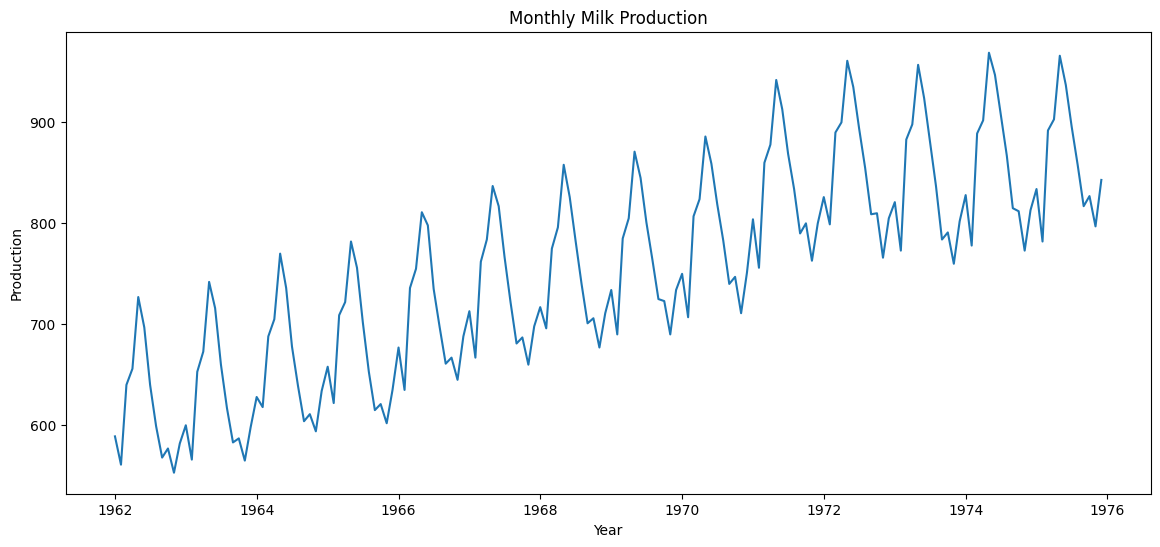

In [11]:
# Time Series Plot
plt.figure(figsize=(14,6))
plt.plot(df['Production'])
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

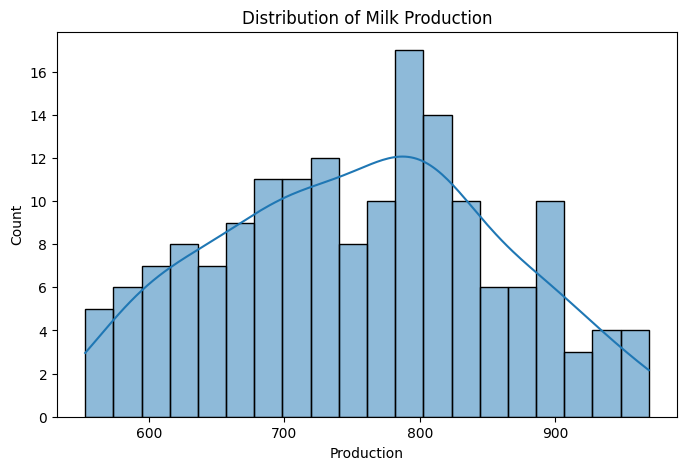

In [12]:
#Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(df['Production'],bins=20,kde=True)
plt.title("Distribution of Milk Production")
plt.show()

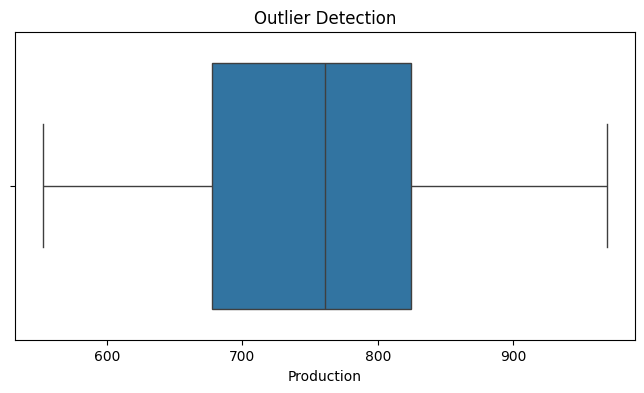

In [13]:
#Boxplot for Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Production'])
plt.title("Outlier Detection")
plt.show()

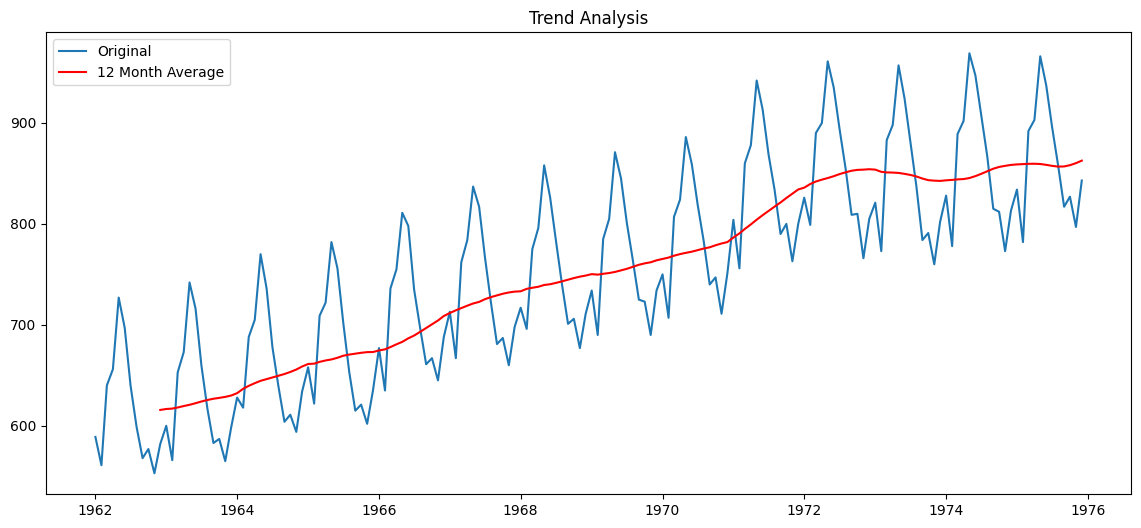

In [14]:
#Rolling Mean
df['Rolling_Mean'] = df['Production'].rolling(window=12).mean()
plt.figure(figsize=(14,6))
plt.plot(df['Production'], label='Original')
plt.plot(df['Rolling_Mean'], color='red', label='12 Month Average')
plt.legend()
plt.title("Trend Analysis")
plt.show()

In [15]:
# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production']])
print(scaled_data[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [16]:
# Function to Create Sequences
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)
WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)
print(X.shape)
print(y.shape)

(156, 12, 1)
(156, 1)


In [17]:
# Train Test Split
train_size = int(len(X)*0.8)
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]
print("X Train :", X_train.shape)
print("X Test :", X_test.shape)

X Train : (124, 12, 1)
X Test : (32, 12, 1)


In [18]:
# Model Evaluation Function
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    pred_actual = scaler.inverse_transform(predictions)
    y_actual = scaler.inverse_transform(y_test)
    rmse = np.sqrt(mean_squared_error(y_actual,pred_actual))
    mae = mean_absolute_error(y_actual,pred_actual)
    mape = np.mean(np.abs((y_actual-pred_actual)/y_actual))*100
    return pred_actual, y_actual, rmse, mae, mape

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
# Simple RNN Model
rnn_model = Sequential()
rnn_model.add(
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(WINDOW_SIZE,1)
    )
)
rnn_model.add(Dense(1))
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0065 - val_loss: 0.0081
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0029 - val_loss: 0.0037
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020 - val_loss: 0.0036
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0056
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0031 - val_lo

In [24]:
# LSTM Model
lstm_model = Sequential()
lstm_model.add(
    LSTM(
        50,
        activation='tanh',
        input_shape=(WINDOW_SIZE,1)
    )
)
lstm_model.add(Dense(1))
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.1921 - val_loss: 0.2884
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0692 - val_loss: 0.0580
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0295 - val_loss: 0.0383
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0346 - val_loss: 0.0270
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0266 - val_loss: 0.0444
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0271 - val_loss: 0.0404
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0253 - val_loss: 0.0297
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0246 - val_loss: 0.0273
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0246 - val_loss: 0.0285
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0242 - val_loss: 0.0293


In [27]:
# GRU Model
gru_model = Sequential()
gru_model.add(
    GRU(
        50,
        activation='tanh',
        input_shape=(WINDOW_SIZE,1)
    )
)
gru_model.add(Dense(1))
gru_model.compile(
    optimizer='adam',
    loss='mse'
)
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.2019 - val_loss: 0.3295
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0757 - val_loss: 0.0987
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0334 - val_loss: 0.0260
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0356 - val_loss: 0.0269
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0288 - val_loss: 0.0421
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0263 - val_loss: 0.0561
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0260 - val_loss: 0.0518
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0248 - val_loss: 0.0422
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0238 - val_loss: 0.0363
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0234 - val_loss: 0.0336


In [28]:
# RNN Evaluation
rnn_pred, y_actual, rnn_rmse, rnn_mae, rnn_mape = evaluate_model(
    rnn_model,
    X_test,
    y_test
)
# LSTM Evaluation
lstm_pred, y_actual, lstm_rmse, lstm_mae, lstm_mape = evaluate_model(
    lstm_model,
    X_test,
    y_test
)
# GRU Evaluation
gru_pred, y_actual, gru_rmse, gru_mae, gru_mape = evaluate_model(
    gru_model,
    X_test,
    y_test
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [29]:
# Comparison Table
results = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "RMSE":[rnn_rmse,
            lstm_rmse,
            gru_rmse],
    "MAE":[rnn_mae,
           lstm_mae,
           gru_mae],
    "MAPE":[rnn_mape,
            lstm_mape,
            gru_mape]
})
print(results)
results.sort_values("RMSE")

  Model        RMSE         MAE       MAPE
0   RNN   16.949860   14.311512   1.697836
1  LSTM  224.215377  215.109707  24.738809
2   GRU  239.713697  231.407450  26.658625


,Model,RMSE,MAE,MAPE
0,RNN,16.949860,14.311512,1.697836
1,LSTM,224.215377,215.109707,24.738809
2,GRU,239.713697,231.407450,26.658625


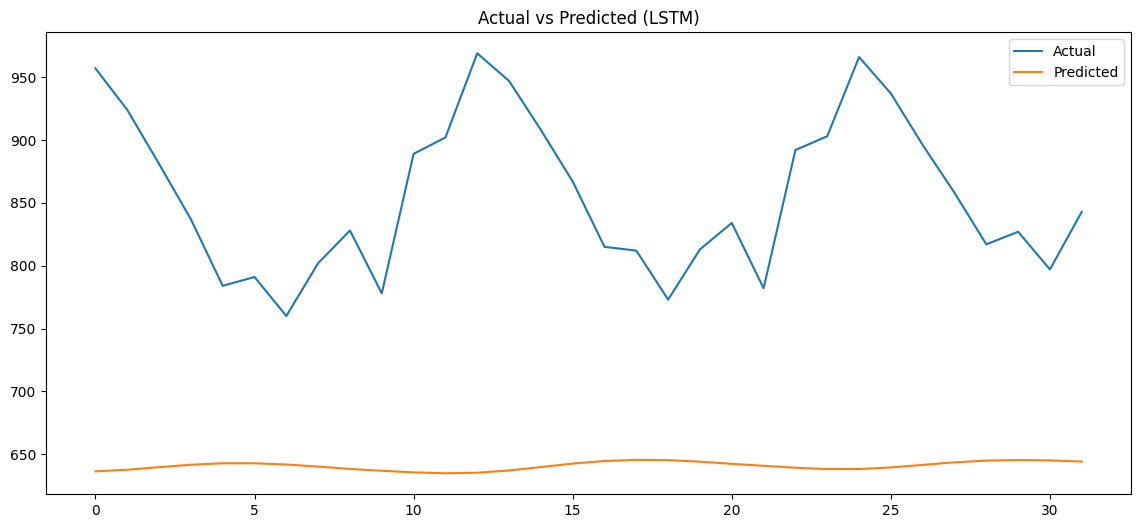

In [30]:
#Plot Actual vs Predicted
plt.figure(figsize=(14,6))
plt.plot(y_actual,label="Actual")
plt.plot(lstm_pred,label="Predicted")
plt.title("Actual vs Predicted (LSTM)")
plt.legend()
plt.show()

In [31]:
best_model = lstm_model

In [32]:
# Future Forecast
future_steps = 12
last_sequence = scaled_data[-WINDOW_SIZE:]
forecast = []
current_seq = last_sequence.copy()
for i in range(future_steps):
    pred = best_model.predict(
        current_seq.reshape(1,
                            WINDOW_SIZE,
                            1),
        verbose=0
    )
    forecast.append(pred[0][0])
    current_seq = np.append(
        current_seq[1:],
        pred
    )
forecast = np.array(forecast).reshape(-1,1)
forecast_actual = scaler.inverse_transform(
    forecast
)
print("Next 12 Month Forecast")
print(forecast_actual)

Next 12 Month Forecast
[[643.0211 ]
 [639.5114 ]
 [634.8318 ]
 [628.55237]
 [622.1262 ]
 [615.622  ]
 [609.8961 ]
 [605.03906]
 [600.9813 ]
 [597.6688 ]
 [594.735  ]
 [592.3867 ]]


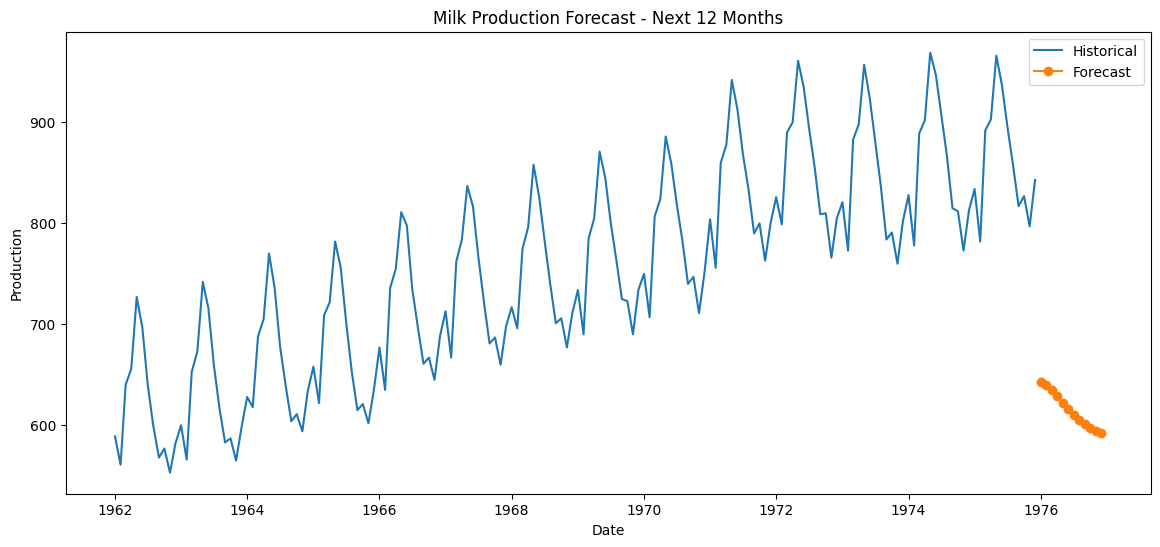

In [33]:
# Forecast Dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)
forecast_df = pd.DataFrame({
    "Date":future_dates,
    "Forecast":forecast_actual.flatten()
})
plt.figure(figsize=(14,6))
plt.plot(df.index,
         df['Production'],
         label='Historical')
plt.plot(forecast_df['Date'],
         forecast_df['Forecast'],
         marker='o',
         label='Forecast')
plt.title("Milk Production Forecast - Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [ ]:
###Key Findings
Milk production exhibits strong seasonality and recurring yearly patterns.
LSTM and GRU generally outperform Simple RNN because they capture long-term patterns better.
Forecasts help management anticipate production peaks and low-production periods
###